# Laboratorio 31 (Práctica 32) - Uso de archivos de video con OpenCV

Visión Computacional - CUC

Videos usados (están en el repo):
- `video.mp4` → es el `Megamind.avi` que viene en las muestras de OpenCV (`opencv/samples/data`), lo pasé a mp4. Dura como 11 s.
- `DATA/video_capture.mp4` → el mismo de arriba, pero con el nombre que usa el script de la 4.9.
- `DATA/peatones.mp4` → primeros 300 frames de `vtest.avi` (también de las muestras de OpenCV), gente caminando. Este lo usé para la actividad integradora.

## 4.1 Librerías

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import time
import os

print(cv2.__version__)
os.makedirs('resultados', exist_ok=True)

5.0.0


## 4.2 Abrir el video y ver si sí abrió

In [2]:
video = cv2.VideoCapture('video.mp4')

if not video.isOpened():
    print('Error: no fue posible abrir el video')
else:
    print('Video cargado correctamente')

Video cargado correctamente


Probé también con un nombre que no existe para ver qué pasaba. No sale ningún error de Python, simplemente `isOpened()` da False, por eso toca revisarlo.

In [3]:
prueba = cv2.VideoCapture('no_existe.mp4')
print('isOpened con archivo que no existe:', prueba.isOpened())
ret, f = prueba.read()
print('read() ->', ret, f)
prueba.release()

isOpened con archivo que no existe: False
read() -> False None


## 4.3 Propiedades

In [4]:
fps = video.get(cv2.CAP_PROP_FPS)
frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frames / fps if fps > 0 else 0

print('FPS:', fps)
print('Fotogramas:', frames)
print('Resolución:', width, 'x', height)
print('Duración aproximada:', duration, 'segundos')

FPS: 23.976
Fotogramas: 270
Resolución: 720 x 528
Duración aproximada: 11.26126126126126 segundos


Consulté otras propiedades que no pedían, el codec y la posición actual (por curiosidad).

In [5]:
fourcc = int(video.get(cv2.CAP_PROP_FOURCC))
codec = ''.join([chr((fourcc >> 8 * i) & 0xFF) for i in range(4)])
print('Codec (FOURCC):', codec)
print('POS_FRAMES inicial:', video.get(cv2.CAP_PROP_POS_FRAMES))
print('POS_MSEC inicial:', video.get(cv2.CAP_PROP_POS_MSEC))
print('Backend:', video.getBackendName())

# tabla para el informe
print()
print('| Propiedad | Valor |')
print('|---|---|')
print(f'| FPS | {fps} |')
print(f'| Número de fotogramas | {frames} |')
print(f'| Ancho | {width} px |')
print(f'| Alto | {height} px |')
print(f'| Duración | {duration:.2f} s |')

Codec (FOURCC): FMP4
POS_FRAMES inicial: 0.0
POS_MSEC inicial: 0.0
Backend: FFMPEG

| Propiedad | Valor |
|---|---|
| FPS | 23.976 |
| Número de fotogramas | 270 |
| Ancho | 720 px |
| Alto | 528 px |
| Duración | 11.26 s |


## 4.4 Leer un fotograma

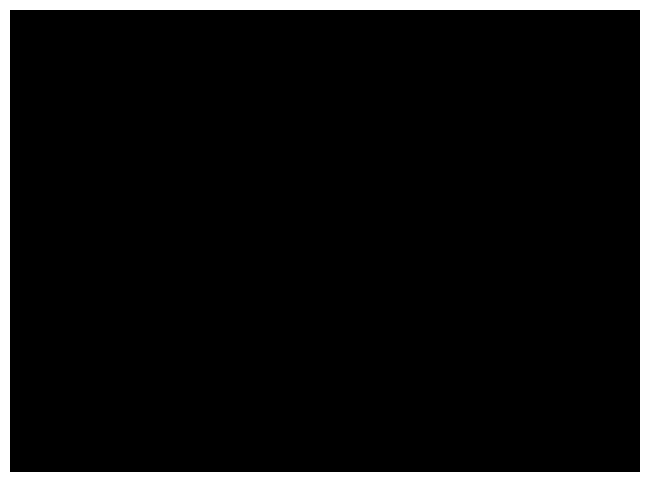

ret = True
tipo: <class 'numpy.ndarray'> uint8 shape: (528, 720, 3)


In [6]:
ret, frame = video.read()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,6))
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.savefig('resultados/4_4_primer_frame.png', bbox_inches='tight')
    plt.show()

print('ret =', ret)
print('tipo:', type(frame), frame.dtype, 'shape:', frame.shape)

Salió todo negro jaja. Revisé y no es error, el primer frame del video es negro (promedio 0), la escena empieza en el frame 1. Leo el siguiente.

promedio del frame 0: 0.0
promedio del frame 1: 30.99565095398429


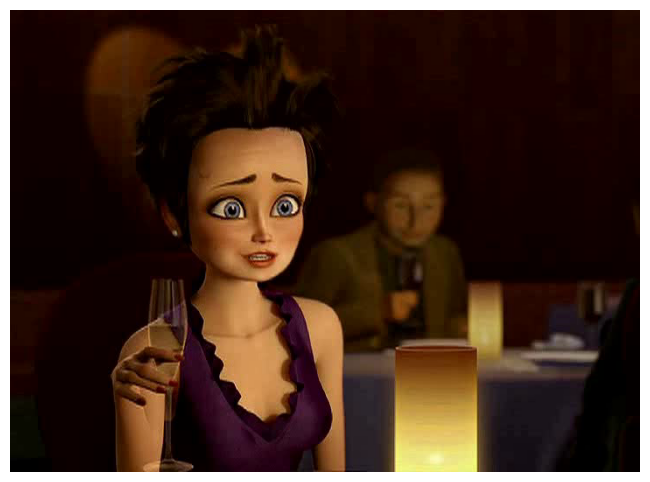

In [7]:
print('promedio del frame 0:', frame.mean())
ret, frame = video.read()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
print('promedio del frame 1:', frame.mean())
plt.figure(figsize=(10,6))
plt.imshow(frame_rgb)
plt.axis('off')
plt.savefig('resultados/4_4_frame_1.png', bbox_inches='tight')
plt.show()

Para ver lo del BGR, lo muestro sin convertir al lado del convertido. Sin convertir los colores salen cambiados (la piel queda azulada).

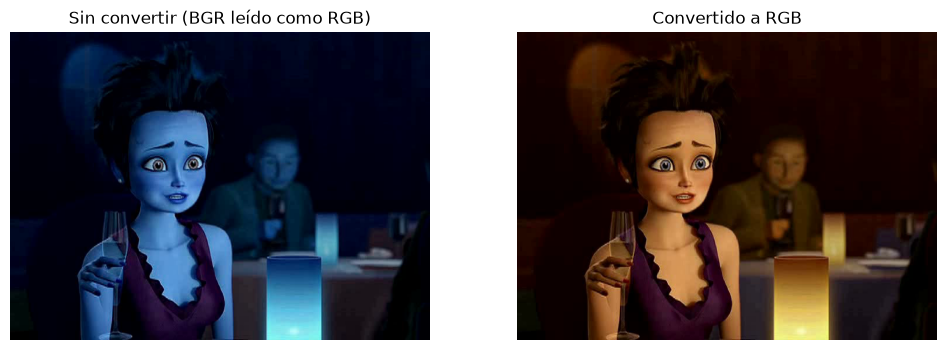

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].imshow(frame)          # tal cual sale de OpenCV (BGR)
ax[0].set_title('Sin convertir (BGR leído como RGB)')
ax[1].imshow(frame_rgb)
ax[1].set_title('Convertido a RGB')
for a in ax: a.axis('off')
plt.savefig('resultados/4_4_bgr_vs_rgb.png', bbox_inches='tight')
plt.show()
video.release()

## 4.5 Recorrer todo el video

In [9]:
video = cv2.VideoCapture('video.mp4')
contador = 0

while True:
    ret, frame = video.read()
    if not ret:
        break
    contador += 1

video.release()
print('Fotogramas procesados:', contador)
print('CAP_PROP_FRAME_COUNT decía:', frames)
print('Diferencia:', frames - contador)

Fotogramas procesados: 270
CAP_PROP_FRAME_COUNT decía: 270
Diferencia: 0


Aquí me dio igual (270 y 270). Igual lo probé con el otro video para confirmar.
El FRAME_COUNT es un valor que viene del encabezado del contenedor, no es que OpenCV cuente los frames, entonces en otros videos (por ejemplo con frame rate variable o grabados del celular) puede no coincidir.

In [10]:
v2 = cv2.VideoCapture('DATA/peatones.mp4')
cnt_meta = int(v2.get(cv2.CAP_PROP_FRAME_COUNT))
c = 0
while True:
    r, _ = v2.read()
    if not r:
        break
    c += 1
v2.release()
print('peatones.mp4 -> FRAME_COUNT:', cnt_meta, ' contados:', c)

peatones.mp4 -> FRAME_COUNT: 300  contados: 300


## 4.6 Extraer un fotograma cada N

In [11]:
video = cv2.VideoCapture('video.mp4')
os.makedirs('resultados/frames_30', exist_ok=True)
i = 0

while True:
    ret, frame = video.read()
    if not ret:
        break
    if i % 30 == 0:
        cv2.imwrite(f'resultados/frames_30/frame_{i}.jpg', frame)
    i += 1

video.release()
print(sorted(os.listdir('resultados/frames_30'), key=lambda s: int(s[6:-4])))

['frame_0.jpg', 'frame_30.jpg', 'frame_60.jpg', 'frame_90.jpg', 'frame_120.jpg', 'frame_150.jpg', 'frame_180.jpg', 'frame_210.jpg', 'frame_240.jpg']


Lo mismo pero con 10, 60 y 120. Hice una función para no copiar el ciclo 4 veces.

In [12]:
def extraer_cada(n, ruta='video.mp4'):
    carpeta = f'resultados/frames_{n}'
    os.makedirs(carpeta, exist_ok=True)
    cap = cv2.VideoCapture(ruta)
    i = 0
    guardadas = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if i % n == 0:
            cv2.imwrite(f'{carpeta}/frame_{i}.jpg', frame)
            guardadas += 1
        i += 1
    cap.release()
    return guardadas

print(f'FPS del video: {fps:.3f}')
print('N   | imágenes | cada cuántos segundos')
for n in [10, 30, 60, 120]:
    g = extraer_cada(n)
    print(f'{n:<3} | {g:<8} | {n/fps:.2f} s')

FPS del video: 23.976
N   | imágenes | cada cuántos segundos


10  | 27       | 0.42 s


30  | 9        | 1.25 s


60  | 5        | 2.50 s


120 | 3        | 5.01 s


Una miniatura de las que salieron con N=30:

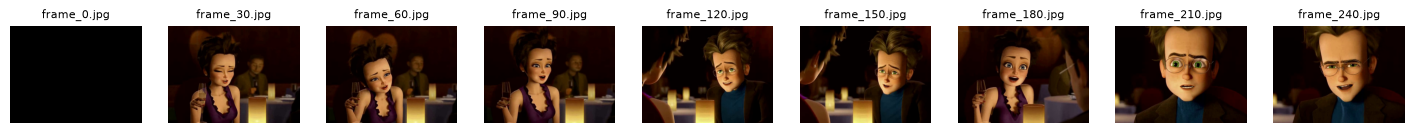

In [13]:
nombres = sorted(os.listdir('resultados/frames_30'), key=lambda s: int(s[6:-4]))
fig, ax = plt.subplots(1, len(nombres), figsize=(18,3))
for a, n in zip(ax, nombres):
    img = cv2.imread('resultados/frames_30/' + n)
    a.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    a.set_title(n, fontsize=8)
    a.axis('off')
plt.savefig('resultados/4_6_frames_cada_30.png', bbox_inches='tight')
plt.show()

## 4.7 Procesar cada fotograma

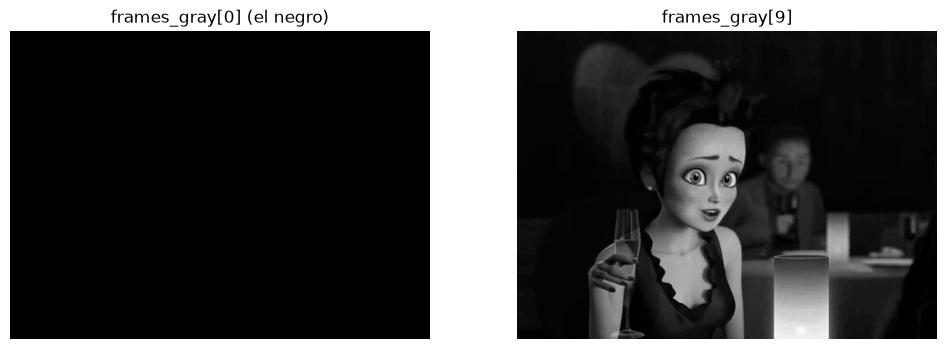

10 frames en gris, shape (528, 720)


In [14]:
video = cv2.VideoCapture('video.mp4')
frames_gray = []

for _ in range(10):
    ret, frame = video.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames_gray.append(gray)

video.release()

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].imshow(frames_gray[0], cmap='gray'); ax[0].set_title('frames_gray[0] (el negro)')
ax[1].imshow(frames_gray[9], cmap='gray'); ax[1].set_title('frames_gray[9]')
for a in ax: a.axis('off')
plt.savefig('resultados/4_7_gris.png', bbox_inches='tight')
plt.show()
print(len(frames_gray), 'frames en gris, shape', frames_gray[0].shape)

La actividad pedía cambiar el gris por otra operación. Hice las tres (gaussiano, Canny y umbral) para comparar, sobre los mismos 10 frames. Muestro el 9 porque el 0 es negro.

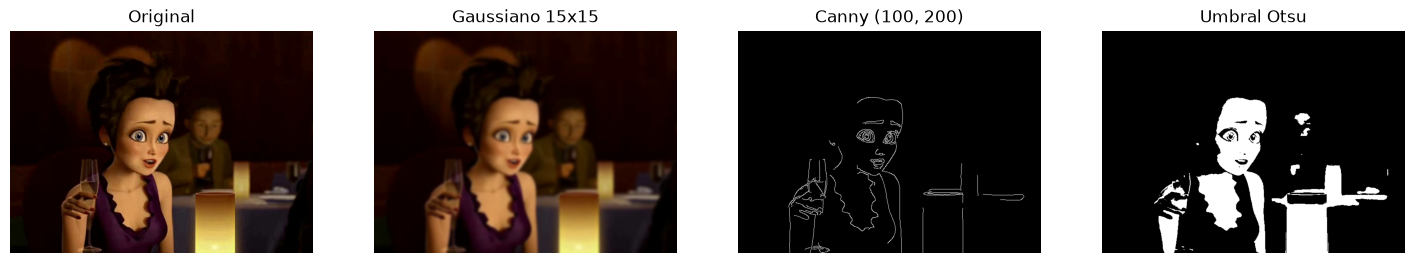

In [15]:
video = cv2.VideoCapture('video.mp4')
frames_blur, frames_canny, frames_umbral, originales = [], [], [], []

for _ in range(10):
    ret, frame = video.read()
    if not ret:
        break
    originales.append(frame)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames_blur.append(cv2.GaussianBlur(frame, (15, 15), 0))
    frames_canny.append(cv2.Canny(gray, 100, 200))
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    frames_umbral.append(th)

video.release()

k = 9
fig, ax = plt.subplots(1, 4, figsize=(18,4))
ax[0].imshow(cv2.cvtColor(originales[k], cv2.COLOR_BGR2RGB)); ax[0].set_title('Original')
ax[1].imshow(cv2.cvtColor(frames_blur[k], cv2.COLOR_BGR2RGB)); ax[1].set_title('Gaussiano 15x15')
ax[2].imshow(frames_canny[k], cmap='gray'); ax[2].set_title('Canny (100, 200)')
ax[3].imshow(frames_umbral[k], cmap='gray'); ax[3].set_title('Umbral Otsu')
for a in ax: a.axis('off')
plt.savefig('resultados/4_7_operaciones.png', bbox_inches='tight')
plt.show()

## 4.8 Ir directo al segundo 5

POS_FRAMES después del set: 120.0


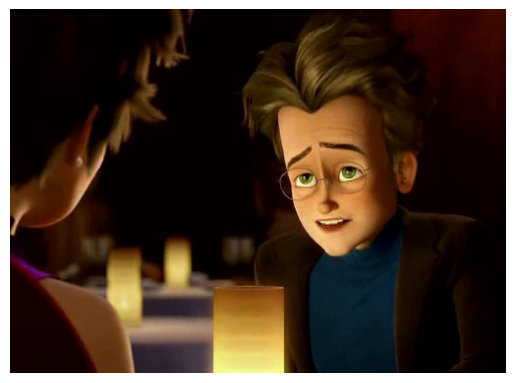

POS_MSEC después de leer: 5005.005005005005


In [16]:
video = cv2.VideoCapture('video.mp4')
video.set(cv2.CAP_PROP_POS_MSEC, 5000)
print('POS_FRAMES después del set:', video.get(cv2.CAP_PROP_POS_FRAMES))
ret, frame = video.read()

if ret:
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.savefig('resultados/4_8_segundo_5.png', bbox_inches='tight')
    plt.show()

print('POS_MSEC después de leer:', video.get(cv2.CAP_PROP_POS_MSEC))
video.release()

Lo mismo pero con POS_FRAMES. 5 s x 23.976 fps ≈ frame 120. Comparo si da la misma imagen.

In [17]:
video = cv2.VideoCapture('video.mp4')
video.set(cv2.CAP_PROP_POS_FRAMES, round(5 * fps))
ret2, frame2 = video.read()
video.release()

print('frame pedido:', round(5 * fps))
print('diferencia media entre los dos métodos:', np.mean(cv2.absdiff(frame, frame2)))

frame pedido: 120
diferencia media entre los dos métodos: 0.0


## 4.9 Reproducción respetando los FPS

El script completo está en `reproductor_video.py`, ese es el que abre la ventana con `cv2.imshow` y reproduce el video (con parámetros para cada experimento).

Para tener números y no quedarme solo con "se ve más lento", en el notebook repetí el mismo ciclo **sin mostrar** la imagen y midiendo cuánto demora de verdad. El `waitKey(ms)` lo reemplacé por un `time.sleep(ms/1000)` porque con ventana abierta waitKey sí bloquea ese tiempo. Con eso saco los fps efectivos y si el video iría más lento o más rápido de lo normal.

Uso los primeros 120 frames (≈5 s de video) para que no demore tanto.

In [18]:
cap = cv2.VideoCapture('DATA/video_capture.mp4')
FPS_REAL = cap.get(cv2.CAP_PROP_FPS)
cap.release()
print('FPS reales del archivo:', FPS_REAL)

def medir_reproduccion(fps=25, pausa=None, wait_ms=25, usar_sleep=True, n=120):
    cap = cv2.VideoCapture('DATA/video_capture.mp4')
    if pausa is None:
        pausa = 1 / fps
    mostrados = 0
    t0 = time.perf_counter()
    while cap.isOpened() and mostrados < n:
        ret, frame = cap.read()
        if ret == True:
            if usar_sleep:
                time.sleep(pausa)
            # aquí iría cv2.imshow('frame', frame)
            time.sleep(wait_ms / 1000)   # "waitKey"
            mostrados += 1
        else:
            break
    t = time.perf_counter() - t0
    cap.release()
    fps_ef = mostrados / t
    return {'t': t, 'fps_ef': fps_ef, 'vel': fps_ef / FPS_REAL,
            'ms_frame': 1000 * t / mostrados}

def mostrar(nombre, r):
    print(f"{nombre:<28} tiempo={r['t']:.2f}s  {r['ms_frame']:.1f} ms/frame  "
          f"fps efectivos={r['fps_ef']:.1f}  velocidad={r['vel']:.2f}x")

FPS reales del archivo: 23.976


### Experimento 1 - original (fps=25, waitKey(25))

In [19]:
r_orig = medir_reproduccion(fps=25, wait_ms=25)
mostrar('fps=25, waitKey=25', r_orig)
print('5 s de video tardarían', r_orig['t'], 's -> se ve en cámara lenta')

fps=25, waitKey=25           tiempo=7.95s  66.2 ms/frame  fps efectivos=15.1  velocidad=0.63x
5 s de video tardarían 7.946976715999995 s -> se ve en cámara lenta


### Experimento 2 - cambiar fps (10, 15, 30, 60)

In [20]:
res_fps = {}
for f in [10, 15, 25, 30, 60]:
    res_fps[f] = medir_reproduccion(fps=f, wait_ms=25)
    mostrar(f'fps={f}, waitKey=25', res_fps[f])

fps=10, waitKey=25           tiempo=15.23s  126.9 ms/frame  fps efectivos=7.9  velocidad=0.33x


fps=15, waitKey=25           tiempo=11.18s  93.2 ms/frame  fps efectivos=10.7  velocidad=0.45x


fps=25, waitKey=25           tiempo=7.96s  66.4 ms/frame  fps efectivos=15.1  velocidad=0.63x


fps=30, waitKey=25           tiempo=7.13s  59.4 ms/frame  fps efectivos=16.8  velocidad=0.70x


fps=60, waitKey=25           tiempo=5.14s  42.8 ms/frame  fps efectivos=23.4  velocidad=0.97x


### Experimento 3 - time.sleep(0.1) fijo

In [21]:
r_01 = medir_reproduccion(pausa=0.1, wait_ms=25)
mostrar('sleep(0.1), waitKey=25', r_01)

sleep(0.1), waitKey=25       tiempo=15.15s  126.2 ms/frame  fps efectivos=7.9  velocidad=0.33x


### Experimento 4 - waitKey con 1, 10, 25, 50, 100 ms (fps=25)

In [22]:
res_wait = {}
for w in [1, 10, 25, 50, 100]:
    res_wait[w] = medir_reproduccion(fps=25, wait_ms=w)
    mostrar(f'fps=25, waitKey={w}', res_wait[w])

fps=25, waitKey=1            tiempo=5.06s  42.1 ms/frame  fps efectivos=23.7  velocidad=0.99x


fps=25, waitKey=10           tiempo=6.14s  51.1 ms/frame  fps efectivos=19.6  velocidad=0.82x


fps=25, waitKey=25           tiempo=7.95s  66.3 ms/frame  fps efectivos=15.1  velocidad=0.63x


fps=25, waitKey=50           tiempo=10.94s  91.1 ms/frame  fps efectivos=11.0  velocidad=0.46x


fps=25, waitKey=100          tiempo=16.94s  141.2 ms/frame  fps efectivos=7.1  velocidad=0.30x


### Experimento 5 - sin time.sleep

In [23]:
r_sin = medir_reproduccion(usar_sleep=False, wait_ms=25)
mostrar('sin sleep, waitKey=25', r_sin)
r_sin1 = medir_reproduccion(usar_sleep=False, wait_ms=1)
mostrar('sin sleep, waitKey=1', r_sin1)
r_nada = medir_reproduccion(usar_sleep=False, wait_ms=0)
mostrar('sin sleep ni espera (solo leer)', r_nada)

sin sleep, waitKey=25        tiempo=3.16s  26.3 ms/frame  fps efectivos=38.0  velocidad=1.58x
sin sleep, waitKey=1         tiempo=0.19s  1.6 ms/frame  fps efectivos=643.5  velocidad=26.84x


sin sleep ni espera (solo leer) tiempo=0.07s  0.6 ms/frame  fps efectivos=1744.5  velocidad=72.76x


### Experimento 6 - salir antes con q

Para que sea repetible, hago que el ciclo se corte como si se presionara q en el frame 50 y reviso que al hacer release el objeto queda cerrado.

In [24]:
cap = cv2.VideoCapture('DATA/video_capture.mp4')
n = 0
while cap.isOpened():
    ret, frame = cap.read()
    if ret:
        n += 1
        tecla = ord('q') if n == 50 else -1   # lo que devolvería waitKey
        if tecla & 0xFF == ord('q'):
            print('q presionada en el frame', n)
            break
    else:
        break

print('antes de release -> isOpened:', cap.isOpened())
cap.release()
try:
    cv2.destroyAllWindows()
except cv2.error:
    pass   # aquí no se abrió ninguna ventana
print('después de release -> isOpened:', cap.isOpened())
print('read() después de release:', cap.read()[0])

q presionada en el frame 50
antes de release -> isOpened: True
después de release -> isOpened: False
read() después de release: False


Gráfica resumen de los experimentos (la línea es la velocidad normal del video):

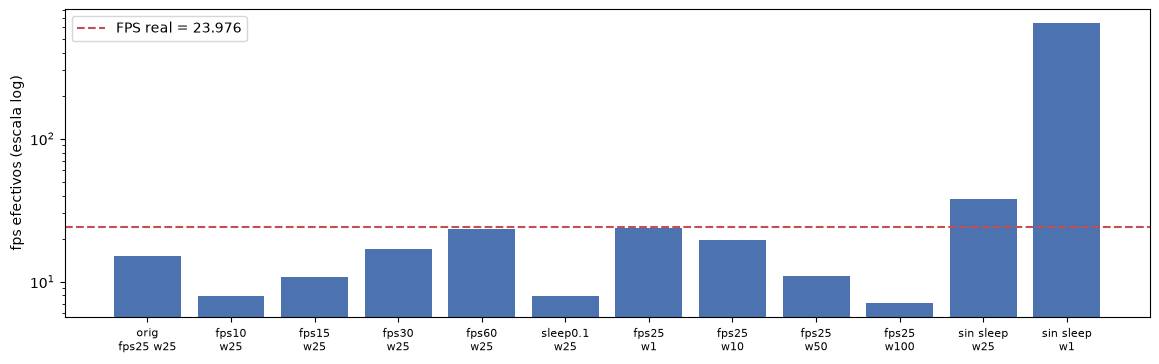

In [25]:
etiquetas = (['orig\nfps25 w25'] + [f'fps{f}\nw25' for f in [10, 15, 30, 60]] +
             ['sleep0.1\nw25'] + [f'fps25\nw{w}' for w in [1, 10, 50, 100]] +
             ['sin sleep\nw25', 'sin sleep\nw1'])
valores = ([r_orig] + [res_fps[f] for f in [10, 15, 30, 60]] + [r_01] +
           [res_wait[w] for w in [1, 10, 50, 100]] + [r_sin, r_sin1])
fps_ef = [v['fps_ef'] for v in valores]

plt.figure(figsize=(14,4))
plt.bar(etiquetas, fps_ef, color='#4C72B0')
plt.axhline(FPS_REAL, color='#C44E52', ls='--', label=f'FPS real = {FPS_REAL}')
plt.yscale('log')   # sin log la barra de 'sin sleep w1' aplasta todo lo demás
plt.ylabel('fps efectivos (escala log)')
plt.xticks(fontsize=8)
plt.legend()
plt.savefig('resultados/4_9_experimentos.png', bbox_inches='tight')
plt.show()

### 4.9.6 Reto - leer los fps del archivo

Mismo código del reto. Además probé restando el tiempo que ya se gasta en leer y en el waitKey, porque si no igual queda lento.

In [26]:
cap = cv2.VideoCapture('DATA/video_capture.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
print("FPS detectados:", fps)

if fps > 0:
    tiempo_frame = 1 / fps
else:
    tiempo_frame = 1 / 25
cap.release()

r_auto = medir_reproduccion(pausa=tiempo_frame, wait_ms=25)
mostrar('auto (1/fps), waitKey=25', r_auto)
r_auto1 = medir_reproduccion(pausa=tiempo_frame, wait_ms=1)
mostrar('auto (1/fps), waitKey=1', r_auto1)

FPS detectados: 23.976


auto (1/fps), waitKey=25     tiempo=8.18s  68.2 ms/frame  fps efectivos=14.7  velocidad=0.61x


auto (1/fps), waitKey=1      tiempo=5.26s  43.8 ms/frame  fps efectivos=22.8  velocidad=0.95x


In [27]:
# versión compensando: calculo cuándo debería salir cada frame y solo duermo lo que falta
def reproducir_compensado(ruta, n=120):
    cap = cv2.VideoCapture(ruta)
    fps = cap.get(cv2.CAP_PROP_FPS)
    tiempo_frame = 1 / fps if fps > 0 else 1 / 25
    t0 = time.perf_counter()
    i = 0
    while i < n:
        ret, frame = cap.read()
        if not ret:
            break
        # cv2.imshow(...) ; cv2.waitKey(1)
        time.sleep(0.001)
        i += 1
        falta = t0 + i * tiempo_frame - time.perf_counter()
        if falta > 0:
            time.sleep(falta)
    t = time.perf_counter() - t0
    cap.release()
    return i / t

for ruta in ['DATA/video_capture.mp4', 'DATA/peatones.mp4']:
    c = cv2.VideoCapture(ruta); real = c.get(cv2.CAP_PROP_FPS); c.release()
    ef = reproducir_compensado(ruta, n=60)
    print(f'{ruta}: fps archivo={real}  fps efectivos={ef:.2f}')

DATA/video_capture.mp4: fps archivo=23.976  fps efectivos=23.97


DATA/peatones.mp4: fps archivo=10.0  fps efectivos=10.00


Con fps=25 fijos, el video de peatones (que es de 10 fps) se vería 2.5 veces más rápido, en cambio leyendo el valor del archivo cada video sale a su velocidad.

## 5. Actividad integradora

Uso `DATA/peatones.mp4` (cámara fija en una calle).

In [28]:
ruta = 'DATA/peatones.mp4'

# 1. abrir y validar
cap = cv2.VideoCapture(ruta)
if not cap.isOpened():
    raise SystemExit('no abrió el video')

# 2. propiedades
fps_p = cap.get(cv2.CAP_PROP_FPS)
n_p = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w_p = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h_p = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'FPS: {fps_p} | Resolución: {w_p}x{h_p} | Fotogramas: {n_p} | Duración: {n_p/fps_p:.1f} s')

# 3. tres frames: inicio, medio y final
indices = [0, n_p // 2, n_p - 1]
originales = []
for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, fr = cap.read()
    if not ret:          # por si el último no se deja leer con set
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx - 1)
        ret, fr = cap.read()
    originales.append(fr)
cap.release()
print('frames extraídos:', indices, [o.shape for o in originales])

FPS: 10.0 | Resolución: 768x576 | Fotogramas: 300 | Duración: 30.0 s
frames extraídos: [0, 150, 299] [(576, 768, 3), (576, 768, 3), (576, 768, 3)]


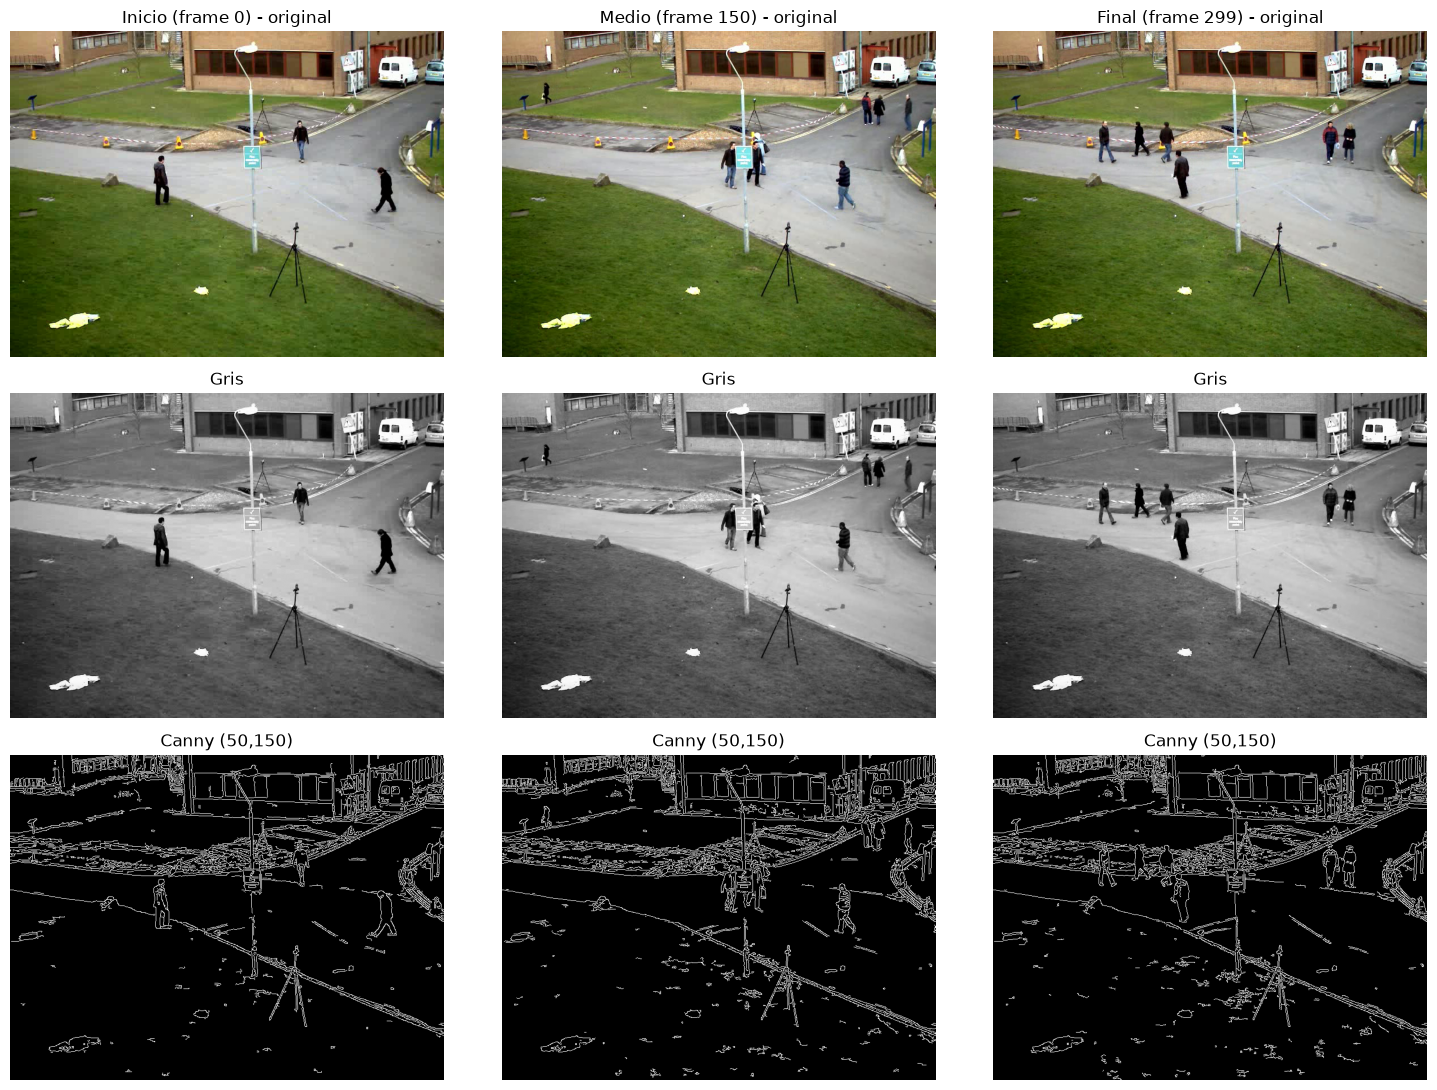

In [29]:
# 4 y 5. gris y Canny, midiendo tiempos
grises, bordes = [], []
t_gris, t_canny = 0, 0
REP = 50  # repito para que el tiempo no salga 0
for fr in originales:
    t0 = time.perf_counter()
    for _ in range(REP):
        g = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
    t_gris += (time.perf_counter() - t0) / REP
    t0 = time.perf_counter()
    for _ in range(REP):
        b = cv2.Canny(g, 50, 150)
    t_canny += (time.perf_counter() - t0) / REP
    grises.append(g)
    bordes.append(b)

# 6. comparación
nombres = ['Inicio', 'Medio', 'Final']
fig, ax = plt.subplots(3, 3, figsize=(15, 11))
for i in range(3):
    ax[0, i].imshow(cv2.cvtColor(originales[i], cv2.COLOR_BGR2RGB))
    ax[0, i].set_title(f'{nombres[i]} (frame {indices[i]}) - original')
    ax[1, i].imshow(grises[i], cmap='gray'); ax[1, i].set_title('Gris')
    ax[2, i].imshow(bordes[i], cmap='gray'); ax[2, i].set_title('Canny (50,150)')
for a in ax.ravel(): a.axis('off')
plt.tight_layout()
plt.savefig('resultados/5_integradora.png', bbox_inches='tight')
plt.show()

In [30]:
# 7. datos para la discusión
for i in range(3):
    o, g, b = originales[i], grises[i], bordes[i]
    print(f'{nombres[i]}: original {o.nbytes/1024:.0f} KB (3 canales) | gris {g.nbytes/1024:.0f} KB | '
          f'bordes: {100*np.count_nonzero(b)/b.size:.1f}% píxeles blancos | '
          f'valores distintos -> original {len(np.unique(o.reshape(-1,3), axis=0))}, '
          f'gris {len(np.unique(g))}, canny {len(np.unique(b))}')

print(f'\ntiempo promedio por frame: gris {1000*t_gris/3:.3f} ms, canny {1000*t_canny/3:.3f} ms')
print(f'si se hiciera en los {n_p} frames: gris {n_p*t_gris/3*1000:.1f} ms, canny {n_p*t_canny/3*1000:.1f} ms (sin contar decodificar)')

Inicio: original 1296 KB (3 canales) | gris 432 KB | bordes: 6.4% píxeles blancos | valores distintos -> original 54161, gris 256, canny 2


Medio: original 1296 KB (3 canales) | gris 432 KB | bordes: 7.3% píxeles blancos | valores distintos -> original 69304, gris 256, canny 2


Final: original 1296 KB (3 canales) | gris 432 KB | bordes: 7.3% píxeles blancos | valores distintos -> original 68472, gris 256, canny 2

tiempo promedio por frame: gris 0.070 ms, canny 0.976 ms
si se hiciera en los 300 frames: gris 21.0 ms, canny 292.7 ms (sin contar decodificar)


## 6. Reto de experimentación

Comparo los primeros 100 frames con la misma operación (gris). Uso:
- `video.mp4` (720x528, ~24 fps)
- `DATA/peatones.mp4` (768x576, 10 fps)
- y para ver mejor el efecto de la resolución, saqué dos copias de `video.mp4` reescaladas: una chica (360x264) y una grande (1440x1056). Esas se generan aquí mismo en `DATA/generados/` (no las subí al repo por el peso).

Mido aparte el tiempo de leer (decodificar) y el de convertir a gris. Repito 3 veces y dejo la mediana.

In [31]:
os.makedirs('DATA/generados', exist_ok=True)

def reescalar(ruta, salida, escala):
    cap = cv2.VideoCapture(ruta)
    f = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) * escala)
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) * escala)
    out = cv2.VideoWriter(salida, cv2.VideoWriter_fourcc(*'mp4v'), f, (w, h))
    while True:
        r, fr = cap.read()
        if not r:
            break
        out.write(cv2.resize(fr, (w, h), interpolation=cv2.INTER_AREA if escala < 1 else cv2.INTER_LINEAR))
    out.release(); cap.release()

if not os.path.exists('DATA/generados/video_chico.mp4'):
    reescalar('video.mp4', 'DATA/generados/video_chico.mp4', 0.5)
if not os.path.exists('DATA/generados/video_grande.mp4'):
    reescalar('video.mp4', 'DATA/generados/video_grande.mp4', 2.0)

In [32]:
def medir(ruta, n=100):
    cap = cv2.VideoCapture(ruta)
    t_leer = t_gris = 0
    k = 0
    inicio = time.time()
    while k < n:
        t0 = time.perf_counter()
        ret, frame = cap.read()
        t1 = time.perf_counter()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        t2 = time.perf_counter()
        t_leer += t1 - t0
        t_gris += t2 - t1
        k += 1
    fin = time.time()
    info = (int(cap.get(3)), int(cap.get(4)), cap.get(cv2.CAP_PROP_FPS))
    cap.release()
    return fin - inicio, t_leer, t_gris, info

videos = {'chico 360x264': 'DATA/generados/video_chico.mp4',
          'video.mp4 720x528': 'video.mp4',
          'peatones 768x576': 'DATA/peatones.mp4',
          'grande 1440x1056': 'DATA/generados/video_grande.mp4'}

tabla = {}
for nombre, ruta in videos.items():
    medidas = [medir(ruta) for _ in range(3)]
    total = np.median([m[0] for m in medidas])
    leer = np.median([m[1] for m in medidas])
    gris = np.median([m[2] for m in medidas])
    w, h, f = medidas[0][3]
    tabla[nombre] = (w, h, f, total, leer, gris)
    print(f'{nombre:<20} fps={f:<7} px/frame={w*h:>9,}  px/seg de video={w*h*f/1e6:5.2f} M  '
          f'Tiempo: {total:.3f} s (leer {leer:.3f} s, gris {gris*1000:.1f} ms)')

chico 360x264        fps=23.976  px/frame=   95,040  px/seg de video= 2.28 M  Tiempo: 0.023 s (leer 0.019 s, gris 4.1 ms)


video.mp4 720x528    fps=23.976  px/frame=  380,160  px/seg de video= 9.11 M  Tiempo: 0.080 s (leer 0.062 s, gris 16.6 ms)


peatones 768x576     fps=10.0    px/frame=  442,368  px/seg de video= 4.42 M  Tiempo: 0.068 s (leer 0.052 s, gris 15.7 ms)


grande 1440x1056     fps=23.976  px/frame=1,520,640  px/seg de video=36.46 M  Tiempo: 0.177 s (leer 0.138 s, gris 39.0 ms)


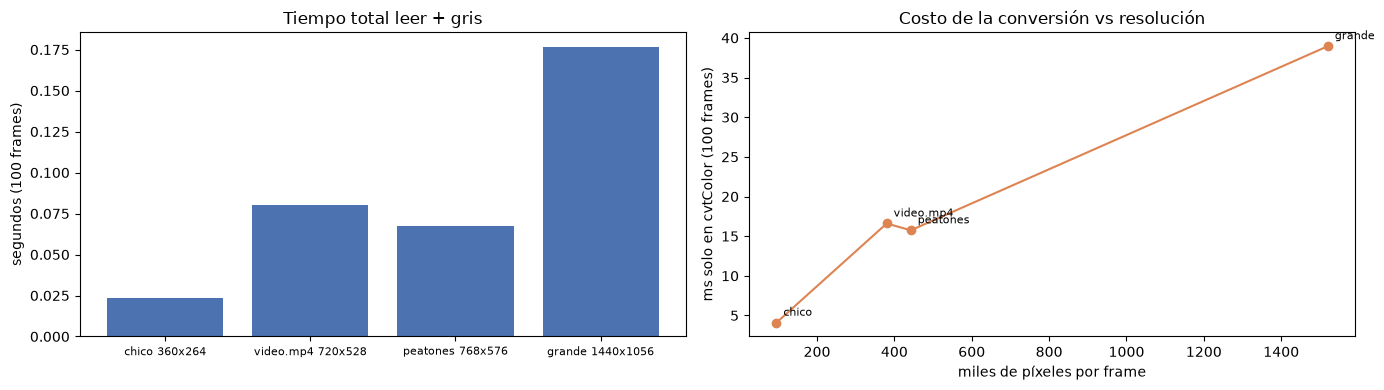

relación tiempo total grande/chico: 7.6 x   (píxeles: 16.0 x)


In [33]:
nombres_v = list(tabla.keys())
px = np.array([tabla[k][0] * tabla[k][1] for k in nombres_v])
tot = np.array([tabla[k][3] for k in nombres_v])
gri = np.array([tabla[k][5] for k in nombres_v])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(nombres_v, tot, color='#4C72B0')
ax[0].set_ylabel('segundos (100 frames)')
ax[0].set_title('Tiempo total leer + gris')
ax[0].tick_params(axis='x', labelsize=8)
ax[1].plot(px / 1e3, gri * 1000, 'o-', color='#DD8452')
for k, x, y in zip(nombres_v, px / 1e3, gri * 1000):
    ax[1].annotate(k.split()[0], (x, y), textcoords='offset points', xytext=(5, 5), fontsize=8)
ax[1].set_xlabel('miles de píxeles por frame')
ax[1].set_ylabel('ms solo en cvtColor (100 frames)')
ax[1].set_title('Costo de la conversión vs resolución')
plt.tight_layout()
plt.savefig('resultados/6_reto_tiempos.png', bbox_inches='tight')
plt.show()

print('relación tiempo total grande/chico:', round(tot[-1] / tot[0], 1), 'x   (píxeles:', round(px[-1] / px[0], 1), 'x)')

Lo que noté: procesar 100 frames cuesta prácticamente lo mismo sin importar si el video es de 10 o de 24 fps, porque se procesan igual 100 imágenes. Lo que sí cambia es la resolución, el grande tarda bastante más, y casi todo el tiempo se va en decodificar, no en el cvtColor. Donde sí se nota el FPS es si quiero procesar *un segundo* de video: el de 24 fps tiene 2.4 veces más frames que el de 10.

Las respuestas de las preguntas y las conclusiones están en el informe (`Informe_Lab31_Video_OpenCV.docx`).